In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 34.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import re

import nltk
import spacy

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import Word2Vec

import matplotlib.pyplot as plt

nltk.download('punkt')
nltk.download('stopwords')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nlp = spacy.load("en_core_web_sm")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [4]:
dataset = load_dataset("imdb")
df = pd.DataFrame(dataset['train'])

texts = df['text']

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [5]:
print("Sample Data:")
print(df.head())

print("\nNumber of samples:", len(df))
print("count:\n",df.value_counts('label'))

Sample Data:
                                                text  label
0  I rented I AM CURIOUS-YELLOW from my video sto...      0
1  "I Am Curious: Yellow" is a risible and preten...      0
2  If only to avoid making this type of film in t...      0
3  This film was probably inspired by Godard's Ma...      0
4  Oh, brother...after hearing about this ridicul...      0

Number of samples: 25000
count:
 label
0    12500
1    12500
Name: count, dtype: int64


In [6]:
#  CLEANING
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

cleaned = texts.apply(clean_text)


#TOKENIZATION
tokenized = cleaned.apply(word_tokenize)


# STOPWORD REMOVAL
stop_words = set(stopwords.words('english'))

filtered = tokenized.apply(
    lambda tokens: [w for w in tokens if w not in stop_words]
)


# LEMMATIZATION
def lemmatize(tokens):
    doc = nlp(" ".join(tokens))
    return [token.lemma_ for token in doc]

lemmatized = filtered.apply(lemmatize)

In [7]:
texts_joined = lemmatized.apply(lambda x: " ".join(x))

tfidf = TfidfVectorizer()
tfidf_vectors = tfidf.fit_transform(texts_joined)


# 5.2 WORD EMBEDDINGS
word2vec = Word2Vec(
    sentences=lemmatized,
    vector_size=100,
    window=5,
    min_count=2
)


# 5.3 SENTENCE EMBEDDINGS
def sentence_vector(tokens):
    vectors = [word2vec.wv[w] for w in tokens if w in word2vec.wv]
    if len(vectors) == 0:
        return np.zeros(100)
    return np.mean(vectors, axis=0)

sentence_embeddings = np.array(
    lemmatized.apply(sentence_vector).tolist()
)


In [8]:
def search(query, sentiment=1):
    indices = df[df['label'] == sentiment].index

    query = clean_text(query)
    tokens = word_tokenize(query)
    tokens = [w for w in tokens if w not in stop_words]
    tokens = lemmatize(tokens)

    query_vec = tfidf.transform([" ".join(tokens)])

    similarities = cosine_similarity(query_vec, tfidf_vectors[indices])[0]

    top_idx = similarities.argsort()[-5:][::-1]

    return [(texts[indices[i]], similarities[i]) for i in top_idx]

In [9]:
results = search("This movie was amazing and thrilling")

for text, score in results:
    print("\nScore:", score)
    print(text[:200])



Score: 0.22252450564375062
The first time I saw this episode was like a shock to me, it was actually the first time I saw "24". The speed things are happening is amazing, and it's so surprising, thrilling, and even interesting,

Score: 0.1982003737890033
I remember this movie from when i was 12, it was amazing.. i remember it to the day not like most thing i watched back then, i have even tried to buy it but its like rocking horse sh*t! Anyway, the ac

Score: 0.19358525611050906
This movie was incredible. I would recommend it to anyone, much better than what I had already anticipated. It was definitely a heart-wrenching spectacular movie. It is an amazing story, with amazing 

Score: 0.18240256832283672
Oh yeah! Jenna Jameson did it again! Yeah Baby! This movie rocks. It was one of the 1st movies i saw of her. And i have to say i feel in love with her, she was great in this move.<br /><br />Her perfo

Score: 0.16754277174849463
This is a taut suspenseful masterpiece from Brian De Palm

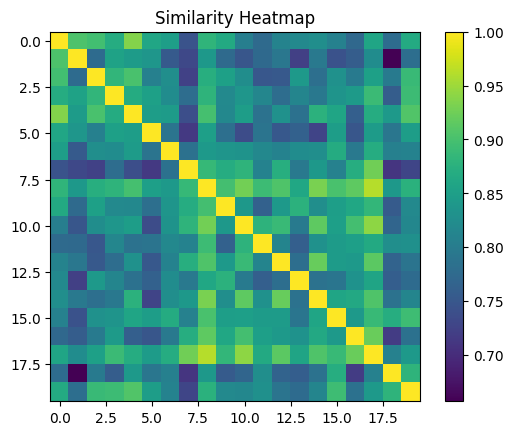

In [10]:
sim_matrix = cosine_similarity(sentence_embeddings[:20])

plt.imshow(sim_matrix)
plt.title("Similarity Heatmap")
plt.colorbar()
plt.show()

In [11]:
from collections import Counter

all_words = [word for tokens in lemmatized for word in tokens]

word_freq = Counter(all_words)

print(word_freq.most_common(10))

[('br', 101871), ('movie', 51705), ('film', 47948), ('one', 27742), ('see', 23559), ('make', 23288), ('like', 22264), ('good', 20170), ('well', 17948), ('get', 17657)]


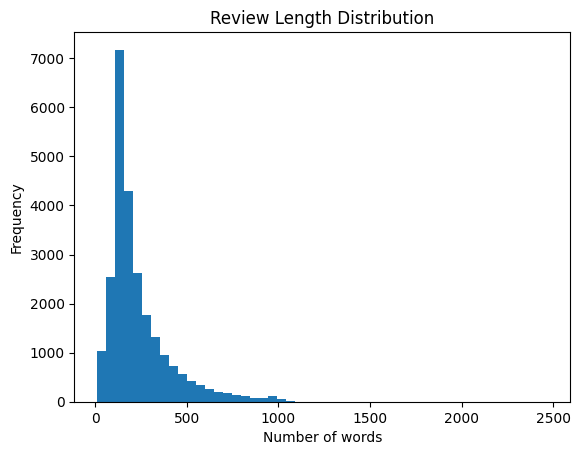

In [12]:
review_lengths = df['text'].apply(lambda x: len(x.split()))

import matplotlib.pyplot as plt

plt.hist(review_lengths, bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

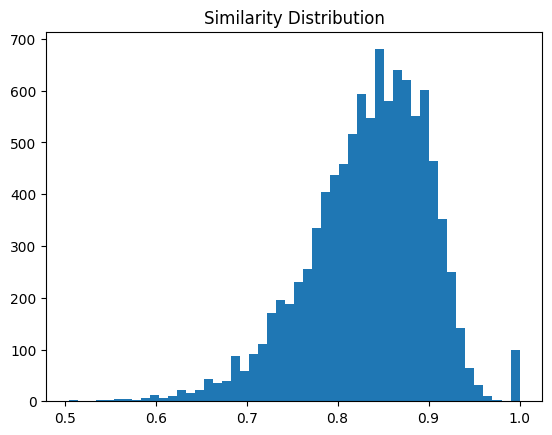

In [14]:
sim_scores = cosine_similarity(sentence_embeddings[:100])

plt.hist(sim_scores.flatten(), bins=50)
plt.title("Similarity Distribution")
plt.show()

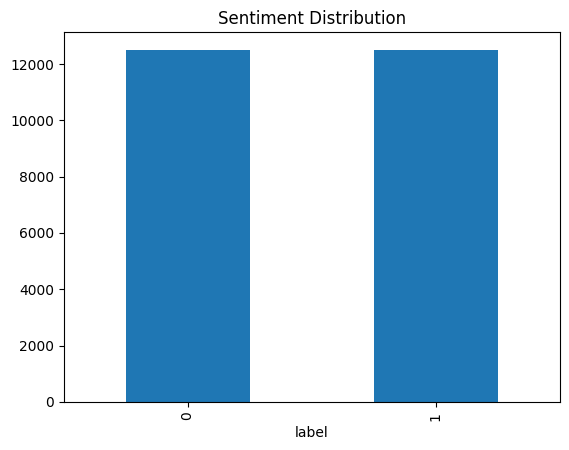

In [15]:
df['label'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.show()